#### 1. Set up the reaction graph from DFT data 

In [1]:
from arcs.generate import GraphGenerator

graph = GraphGenerator().from_file(
    filename='../src/arcs/data/quantum_data.json',
    temperature=248,
    pressure=20,
    max_reaction_length=5,
    log_K = False
)

/Users/badw/github-projects/arcs/src/arcs/generate.py:536: UserWarning: H2O2: 1 imag modes removed
  warnings.warn(f"{compound}: {warn_info['warning']}", UserWarning)
/Users/badw/github-projects/arcs/src/arcs/generate.py:536: UserWarning: CH3CHO: 1 imag modes removed
  warnings.warn(f"{compound}: {warn_info['warning']}", UserWarning)
/Users/badw/github-projects/arcs/src/arcs/generate.py:536: UserWarning: NOHSO4: 2 imag modes removed
  warnings.warn(f"{compound}: {warn_info['warning']}", UserWarning)
/Users/badw/github-projects/arcs/src/arcs/generate.py:536: UserWarning: H2SO4: 1 imag modes removed
  warnings.warn(f"{compound}: {warn_info['warning']}", UserWarning)
/Users/badw/github-projects/arcs/src/arcs/generate.py:536: UserWarning: CH3_CO_CH3: 1 imag modes removed
  warnings.warn(f"{compound}: {warn_info['warning']}", UserWarning)
/Users/badw/github-projects/arcs/src/arcs/generate.py:536: UserWarning: CH3_C6H5: 1 imag modes removed
  warnings.warn(f"{compound}: {warn_info['warning']

#### 2. Sample the `graph`

In [ ]:
from arcs.traversal import Traversal
from arcs.generate import GenerateInitialConcentrations

gic = GenerateInitialConcentrations(graph=graph).update_ic(
    {'H2O':30,'O2':10,'SO2':10,'H2S':10,'NO2':10}
    )

t = Traversal(graph=graph)

data = t.sample(initial_concentrations=gic,ncpus=4,nsamples=1000,**{"use_chempy":True})

  0%|          | 0/1000 [00:00<?, ?it/s]

#### 3. generate reaction statistics

In [3]:
from arcs.analysis import AnalyseSampling
import pandas as pd 

analysis = AnalyseSampling()
stats = pd.Series(analysis.reaction_statistics(data)).sort_values(ascending=False)
stats.head(20)

1 H2 + 1 NO2 = 1 H2O + 1 NO        275
1 SO2 + 1 H2O2 = 1 H2O + 1 SO3     148
1 H2 + 1 SO3 = 1 H2O + 1 SO2       124
2 H2O2 = 2 H2O + 1 O2              112
1 NO + 1 SO3 = 1 NO2 + 1 SO2       108
1 H2SO3 = 1 H2O + 1 SO2            108
1 NO2 + 1 H2O2 = 1 H2O + 1 NO3      96
1 H2O2 + 1 NO = 1 H2O + 1 NO2       96
1 O2 + 2 SO2 = 2 SO3                88
2 HNO2 = 1 H2O + 1 NO2 + 1 NO       80
1 H2SO4 + 1 H2 = 2 H2O + 1 SO2      64
1 NO3 + 1 H2 = 1 H2O + 1 NO2        52
3 H2 + 2 NO2 = 3 H2O + 1 N2O        51
1 NO3 + 1 SO2 = 1 NO2 + 1 SO3       51
4 H2 + 2 NO2 = 4 H2O + 1 N2         47
1 O2 + 2 NO = 2 NO2                 36
3 O2 + 2 H2S = 2 H2O + 2 SO2        32
1 H2O + 2 NO2 = 1 HNO3 + 1 HNO2     28
2 O2 + 1 N2 = 2 NO2                 23
2 NO3 = 1 O2 + 2 NO2                20
dtype: int64

#### 4. generate mean concentrations and differences

In [4]:
average_data = pd.DataFrame(analysis.average_sampling(data))
average_data = average_data.loc[~(average_data==0).all(axis=1)]
average_data.sort_values(by='diff',inplace=True)
print(average_data.round(2).to_string())

        initial   mean  diff   sem   std    var
SO2        10.0   7.60 -2.40  0.10  4.17  17.42
H2O        30.0  29.59 -0.41  0.04  1.64   2.70
NO2        10.0   9.59 -0.41  0.04  1.76   3.11
O2         10.0   9.77 -0.23  0.05  2.06   4.23
NH3         0.0   0.00  0.00  0.00  0.00   0.00
O3          0.0   0.00  0.00  0.00  0.00   0.00
N2          0.0   0.00  0.00  0.00  0.00   0.00
H2          0.0   0.00  0.00  0.00  0.00   0.00
H2S         0.0   0.00  0.00  0.00  0.00   0.00
N2O2        0.0   0.00  0.00  0.00  0.00   0.00
NO3         0.0   0.00  0.00  0.00  0.00   0.00
H2SO3       0.0   0.00  0.00  0.00  0.00   0.00
H2O2        0.0   0.00  0.00  0.00  0.00   0.00
NOHSO4      0.0   0.00  0.00  0.00  0.00   0.00
N2O         0.0   0.01  0.01  0.00  0.16   0.02
S8          0.0   0.03  0.03  0.00  0.17   0.03
NO          0.0   0.07  0.07  0.01  0.26   0.07
HNO2        0.0   0.15  0.15  0.02  0.81   0.66
HNO3        0.0   0.17  0.17  0.02  0.91   0.83
H2SO4       0.0   0.22  0.22  0.03  1.43

#### 5. Plot 

/var/folders/40/xmstzxyn7377k__pn0yxn6w80000gn/T/ipykernel_59004/949321809.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(name='RdBu')  # or any other colormap


<Axes: >

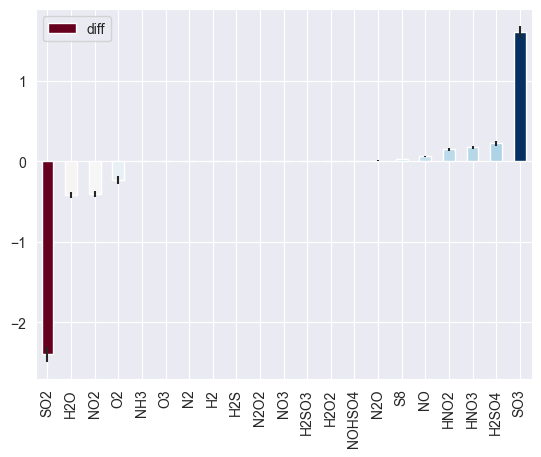

In [5]:
import seaborn as sns 
from matplotlib.cm import get_cmap
import matplotlib.colors as colors
sns.set_style('darkgrid')
sns.set_palette('pastel')


norm = colors.Normalize(
    vmin=average_data['diff'].min(), vmax=average_data['diff'].max()
    )
cmap = get_cmap(name='RdBu')  # or any other colormap

bar_colors = [cmap(norm(value)) for value in average_data['diff']]

average_data.plot.bar(y='diff',yerr='sem',color=bar_colors)

#### 5. generate a `pyvis` graph 

In [ ]:
pyvis_kwargs = {'width':'50%','notebook':False,"font_color":'white','directed':True}
g = analysis.result_to_pyvis(data,head=10,**pyvis_kwargs)
g.save_graph(name="example_pyvis_graph.html")

In [ ]:
! open example_pyvis_graph.html